# Step 07 — Manuscript Evidence and Declaration Scaffold

## tl;dr

This venue-agnostic, manuscript-only phase converts the verified Step 06 blockers into a reproducible submission dossier. It adds primary-source citation candidates, citation insertion points, a CLAIM-2024-aligned gap map, owner-fillable declarations, and a revised manuscript copy with citation keys.

It does **not** claim that owner declarations, ethics, licensing, public availability, venue selection, or venue formatting are complete.

### Immutable boundary

- Read only sealed Part 2 reporting artifacts.
- Never load a model, loader, checkpoint, test image, test mask, or test probability cache.
- Never run inference, change the frozen policy, tune from test results, or reopen test source data.
- Write every new artifact only to this phase's `outputs/` directory.


## Context & Methods

### Key assumptions

- Step 06 is the authoritative readiness audit.
- External sources were verified during notebook construction on 5 August 2026 and are embedded as a reproducible snapshot; Run All requires no network access.
- CLAIM 2024 is used as a venue-agnostic medical-imaging-AI reporting aid, not as a claim of compliance or a substitute for venue instructions.
- Dataset licensing and all personal/institutional declarations remain owner-confirmed fields.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re
import pandas as pd
import matplotlib.pyplot as plt

STEP_DIR = Path.cwd().resolve()
if STEP_DIR.name != "step_07_manuscript_evidence_and_declaration_scaffold":
    candidate = STEP_DIR / "step_07_manuscript_evidence_and_declaration_scaffold"
    if candidate.is_dir(): STEP_DIR = candidate.resolve()
PART2 = STEP_DIR.parent
S5 = PART2 / "step_05_final_research_package" / "outputs"
S6 = PART2 / "step_06_manuscript_submission_readiness_and_archive" / "outputs"
OUT = STEP_DIR / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

MANIFEST_SHA256 = "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
TEST_RUN_ID = "871d289b-bf6b-4346-978f-2df02ade26ab"
CREATED_UTC = datetime.now(timezone.utc).isoformat()

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()
def load_json(path): return json.loads(Path(path).read_text(encoding="utf-8"))
def save_json(obj,name):
    p=OUT/name; p.write_text(json.dumps(obj,indent=2,sort_keys=True),encoding="utf-8"); return p
def save_csv(df,name):
    p=OUT/name; df.to_csv(p,index=False); return p

print("Step directory:",STEP_DIR)
print("Offline artifact-only manuscript mode; no test source paths are defined.")

Step directory: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1 (part 2)\step_07_manuscript_evidence_and_declaration_scaffold
Offline artifact-only manuscript mode; no test source paths are defined.


## Data

### 1. Verify the sealed manuscript inputs and Step 06 decision


In [2]:
s5_gate=load_json(S5/"gate_result.json")
s6_gate=load_json(S6/"gate_result.json")
s6_sig=load_json(S6/"final_archive_signature.json")
paper_path=S5/"PAPER_DRAFT.md"
paper=paper_path.read_text(encoding="utf-8")

checks=[
 ("step05_complete",s5_gate.get("result_level")=="FINAL_PROJECT_COMPLETE",s5_gate.get("result_level")),
 ("formal_failure_preserved",s5_gate.get("formal_model_acceptance_passed") is False,s5_gate.get("formal_model_acceptance_passed")),
 ("step06_complete",s6_gate.get("result_level")=="DIAGNOSTIC_COMPLETE",s6_gate.get("result_level")),
 ("step06_submission_not_ready",s6_gate.get("submission_ready") is False,s6_gate.get("submission_ready")),
 ("step06_next_decision",s6_gate.get("decision")=="COMPLETE_REFERENCES_DECLARATIONS_AND_VENUE_FORMATTING",s6_gate.get("decision")),
 ("manifest_hash",s6_gate.get("manifest_sha256")==MANIFEST_SHA256,s6_gate.get("manifest_sha256")),
 ("test_run_id",s6_gate.get("source_test_run_id")==TEST_RUN_ID,s6_gate.get("source_test_run_id")),
 ("step06_test_rerun_false",s6_gate.get("test_inference_rerun") is False,s6_gate.get("test_inference_rerun")),
 ("step06_sources_reopened_false",s6_gate.get("test_source_files_reopened") is False,s6_gate.get("test_source_files_reopened")),
 ("paper_draft_exists",paper_path.is_file(),str(paper_path)),
]
input_verification=pd.DataFrame(checks,columns=["check","passed","observed"])
save_csv(input_verification,"input_verification.csv")
assert input_verification.passed.all(),input_verification.loc[~input_verification.passed].to_dict("records")
print(f"PASS: {input_verification.passed.sum()}/{len(input_verification)} sealed-input checks")

PASS: 10/10 sealed-input checks


### 2. Curate traceable primary-source citation candidates

The snapshot deliberately contains only foundational or reporting sources that directly support claims already made in the manuscript. Dataset-use terms remain unresolved because no authoritative LiTS licensing statement was verified.


In [3]:
references=pd.DataFrame([
 {"key":"Bilic2023LiTS","role":"dataset and benchmark provenance","title":"The Liver Tumor Segmentation Benchmark (LiTS)","authors":"Bilic P, Christ PF, Li HB, et al.","year":2023,"venue":"Medical Image Analysis 84:102680","doi":"10.1016/j.media.2022.102680","url":"https://www.sciencedirect.com/science/article/pii/S1361841522003085","source_class":"primary benchmark paper","verified_online_date":"2026-08-05","status":"verified_candidate"},
 {"key":"Ronneberger2015UNet","role":"U-Net architecture provenance","title":"U-Net: Convolutional Networks for Biomedical Image Segmentation","authors":"Ronneberger O, Fischer P, Brox T","year":2015,"venue":"MICCAI 2015","doi":"10.1007/978-3-319-24574-4_28","url":"https://arxiv.org/abs/1505.04597","source_class":"primary architecture paper","verified_online_date":"2026-08-05","status":"verified_candidate"},
 {"key":"Sandler2018MobileNetV2","role":"MobileNetV2 encoder provenance","title":"MobileNetV2: Inverted Residuals and Linear Bottlenecks","authors":"Sandler M, Howard A, Zhu M, Zhmoginov A, Chen LC","year":2018,"venue":"CVPR 2018","doi":"10.1109/CVPR.2018.00474","url":"https://openaccess.thecvf.com/content_cvpr_2018/html/Sandler_MobileNetV2_Inverted_Residuals_CVPR_2018_paper","source_class":"primary architecture paper","verified_online_date":"2026-08-05","status":"verified_candidate"},
 {"key":"Tejani2024CLAIM","role":"medical-imaging-AI reporting framework","title":"Checklist for Artificial Intelligence in Medical Imaging (CLAIM): 2024 Update","authors":"Tejani AS, Klontzas ME, Gatti AA, et al.","year":2024,"venue":"Radiology: Artificial Intelligence 6(4):e240300","doi":"10.1148/ryai.240300","url":"https://pubs.rsna.org/doi/10.1148/ryai.240300","source_class":"primary reporting-guideline article","verified_online_date":"2026-08-05","status":"verified_candidate"},
])
save_csv(references,"reference_evidence.csv")

citation_plan=pd.DataFrame([
 ("2.1 Dataset governance","LiTS dataset/challenge identity and heterogeneity","Bilic2023LiTS","insert after first LiTS dataset sentence"),
 ("2.3 Tumour models and fusion","U-Net family architecture","Ronneberger2015UNet","insert after first model-architecture sentence"),
 ("2.3 Tumour models and fusion","MobileNetV2 encoder architecture","Sandler2018MobileNetV2","insert after first model-architecture sentence"),
 ("2.5 Governance and test lock","transparent reporting of medical-imaging AI","Tejani2024CLAIM","cite only as reporting framework, not as claimed compliance"),
 ("Limitations / declarations","reporting gaps and applicability boundaries","Tejani2024CLAIM","cite when describing completed checklist mapping"),
],columns=["manuscript_location","supported_claim","citation_key","insertion_instruction"])
save_csv(citation_plan,"citation_insertion_plan.csv")

bib=[]
for r in references.itertuples(index=False):
    bib.extend([f"@article{{{r.key},",f"  title = {{{r.title}}},",f"  author = {{{r.authors}}},",f"  year = {{{r.year}}},",f"  journal = {{{r.venue}}},",f"  doi = {{{r.doi}}},",f"  url = {{{r.url}}}","}",""])
(OUT/"references.bib").write_text("\n".join(bib),encoding="utf-8")
print(f"Reference candidates: {len(references)}; insertion points: {len(citation_plan)}")

Reference candidates: 4; insertion points: 5


## Results

### 3. Build the reporting-gap and owner-input matrices


In [4]:
claim_rows=[
 ("Title/abstract","AI method, task, data and negative formal outcome identified","complete","PAPER_DRAFT.md","Preserve failed formal acceptance"),
 ("Introduction","Clinical/research context and study objective stated","complete","PAPER_DRAFT.md","Add literature context during editing"),
 ("Data provenance","LiTS identity, corrected build and manifest governance stated","complete","PAPER_DRAFT.md; Step 01 data card","Add Bilic2023LiTS"),
 ("Eligibility and partitions","Patient-disjoint partitions and counts documented","complete","Step 01; Step 05 report","No test re-analysis"),
 ("Reference standard","Label semantics and QC documented","complete","Step 01 outputs","Summarize annotation provenance cautiously"),
 ("Model specification","Architecture, checkpoints and input processing documented","complete","Step 03 policy; Step 05 methods","Add U-Net and MobileNetV2 citations"),
 ("Evaluation design","Frozen one-time held-out evaluation described","complete","Step 03 contract; Step 04 ledger","Do not imply external validation"),
 ("Metrics and uncertainty","Dice, precision, recall, patient bootstrap and strata documented","complete","Step 04/05 outputs","Keep denominators explicit"),
 ("Error analysis","V121 and small-lesion weaknesses reported","complete","Step 05 failure analysis","Recognition failure is evidence-bound"),
 ("Limitations","Cohort, 2D design, calibration and external validity limits stated","complete","Step 05 limitations","No clinical safety claim"),
 ("Ethics/applicability","Ethics determination or public-dataset applicability statement","owner_required","OWNER INPUT","Institutional determination required"),
 ("Data terms","Authoritative dataset-use/license statement","owner_required","OWNER INPUT","Verify acquisition source and terms; do not infer license"),
 ("Code/data availability","Availability and redistribution boundaries","owner_required","OWNER INPUT","Select repository/archive and respect dataset terms"),
 ("Authors/contributions","Names, affiliations and contribution taxonomy","owner_required","OWNER INPUT","Complete CRediT roles if venue supports them"),
 ("Conflicts/funding","Conflict and funding declarations","owner_required","OWNER INPUT","Explicit statements required even if none"),
 ("Venue compliance","Target venue instructions, article type and formatting","venue_required","VENUE INPUT","Complete only after venue selection"),
]
gap_map=pd.DataFrame(claim_rows,columns=["reporting_area","project_evidence_or_requirement","status","evidence_source","required_action"])
save_csv(gap_map,"claim_2024_alignment_gap_map.csv")

metadata=pd.DataFrame([
 ("corresponding_author_name","[OWNER REQUIRED]","owner","blocker"),
 ("author_list_ordered","[OWNER REQUIRED]","owner","blocker"),
 ("affiliations","[OWNER REQUIRED]","owner","blocker"),
 ("orcid_ids","[OWNER OPTIONAL / VENUE DEPENDENT]","owner","pending"),
 ("ethics_applicability_statement","[OWNER/INSTITUTION REQUIRED]","owner_or_institution","blocker"),
 ("dataset_acquisition_source","[OWNER REQUIRED]","owner","blocker"),
 ("dataset_terms_verified","false","owner","blocker"),
 ("author_contributions","[OWNER REQUIRED]","owner","blocker"),
 ("conflicts_of_interest","[OWNER REQUIRED]","owner","blocker"),
 ("funding","[OWNER REQUIRED]","owner","blocker"),
 ("code_repository_or_archive","[OWNER DECISION REQUIRED]","owner","blocker"),
 ("target_venue","[OWNER REQUIRED]","owner","blocker"),
 ("article_type","[VENUE DEPENDENT]","owner_and_venue","blocker"),
],columns=["field","value","responsible_party","readiness_status"])
save_csv(metadata,"submission_metadata_template.csv")

declaration_lines=["# Declaration Template","",
 "Replace every bracketed field with owner-verified information. Do not submit this template with placeholders.","",
 "## Authors and affiliations","[OWNER REQUIRED]","",
 "## Ethics and applicability","[OWNER/INSTITUTION REQUIRED: state the applicable public-dataset/secondary-analysis determination and any approval or exemption identifier.]","",
 "## Dataset terms","[OWNER REQUIRED: record the exact acquisition source, applicable terms/license, permitted publication use, and redistribution restrictions.]","",
 "## Author contributions","[OWNER REQUIRED: contribution roles.]","",
 "## Conflicts of interest","[OWNER REQUIRED: explicit declaration.]","",
 "## Funding","[OWNER REQUIRED: funder and grant identifiers, or explicit no-funding statement.]","",
 "## Code and data availability","[OWNER REQUIRED: repository/archive decision. Do not redistribute LiTS data unless authoritative terms permit it.]","",
 "## Test-governance statement",
 f"The held-out test split was evaluated once under run UUID `{TEST_RUN_ID}` using a policy frozen before access. The completed ledger prohibits rerun or test-driven tuning."]
(OUT/"DECLARATION_TEMPLATE.md").write_text("\n".join(declaration_lines)+"\n",encoding="utf-8")

terms_lines=["# Dataset Terms Verification Record","",
 "Status: **unresolved — owner verification required**.","",
 "The LiTS benchmark paper is verified as the dataset/benchmark citation, but this phase did not find or infer an authoritative license applicable to the user's exact acquired copy.","",
 "Before submission, record:","",
 "1. Exact acquisition portal/source and access date.",
 "2. The terms or license presented at acquisition.",
 "3. Whether derived artifacts, code, labels, or images may be redistributed.",
 "4. Required dataset citation or acknowledgment language.",
 "5. Institutional ethics/applicability determination for this secondary analysis.","",
 "Do not mark dataset terms complete from third-party mirrors or assumptions."]
(OUT/"DATASET_TERMS_VERIFICATION.md").write_text("\n".join(terms_lines)+"\n",encoding="utf-8")
print("Reporting areas:",len(gap_map),"owner/venue gaps:",gap_map.status.ne("complete").sum())

Reporting areas: 16 owner/venue gaps: 6


### 4. Produce a citation-keyed manuscript copy and readiness dashboard


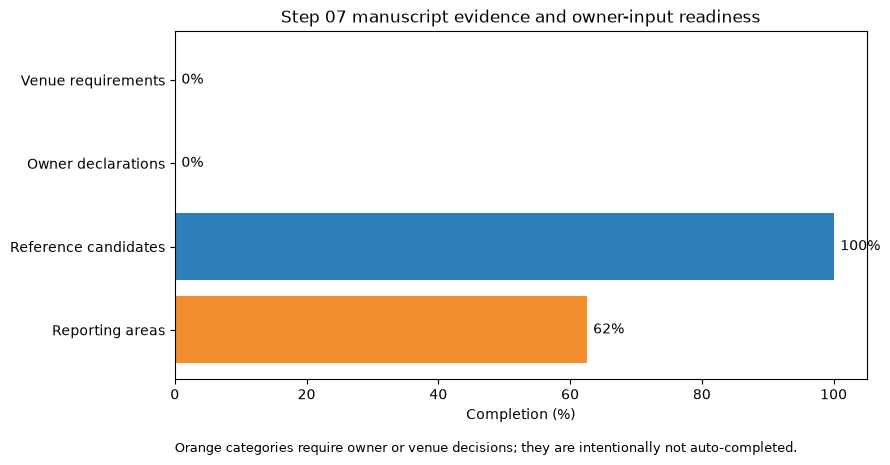

Citation-keyed manuscript saved; submission remains blocked on owner and venue fields.


In [5]:
revised=paper
replacements=[
 ("The study used corrected build", "The study used the LiTS benchmark dataset [Bilic2023LiTS] and corrected build"),
 ("Control and recall-loss MobileNetV2 U-Net checkpoints", "Control and recall-loss U-Net-family [Ronneberger2015UNet] checkpoints with MobileNetV2 encoders [Sandler2018MobileNetV2]"),
 ("The inference policy and formal acceptance table were frozen", "Following a transparent medical-imaging-AI reporting approach [Tejani2024CLAIM], the inference policy and formal acceptance table were frozen"),
]
replacement_log=[]
for old,new in replacements:
    count=revised.count(old); revised=revised.replace(old,new,1)
    replacement_log.append({"source_text":old,"replacement_applied":count==1,"occurrences_before":count})
replacement_log=pd.DataFrame(replacement_log); save_csv(replacement_log,"citation_replacement_log.csv")
assert replacement_log.replacement_applied.all()
revised += "\n\n## Candidate references (verify venue style before submission)\n\n"
for r in references.itertuples(index=False):
    revised += f"- [{r.key}] {r.authors}. {r.title}. {r.venue}. {r.year}. doi:{r.doi}\n"
revised += "\n## Submission declarations\n\n[OWNER REQUIRED: complete `DECLARATION_TEMPLATE.md`; unresolved placeholders prohibit submission.]\n"
(OUT/"PAPER_DRAFT_WITH_CITATION_KEYS.md").write_text(revised,encoding="utf-8")

status_counts=pd.DataFrame([
 ("Reporting areas",int(gap_map.status.eq("complete").sum()),len(gap_map)),
 ("Reference candidates",int(references.status.eq("verified_candidate").sum()),len(references)),
 ("Owner declarations",int(metadata.query("responsible_party.str.contains('owner')",engine="python").readiness_status.eq("complete").sum()),int(metadata.responsible_party.str.contains("owner").sum())),
 ("Venue requirements",0,2),
],columns=["domain","complete","total"])
status_counts["completion_pct"]=100*status_counts.complete/status_counts.total
fig,ax=plt.subplots(figsize=(9,4.8))
colors=["#2c7fb8" if v==100 else "#f28e2b" for v in status_counts.completion_pct]
bars=ax.barh(status_counts.domain,status_counts.completion_pct,color=colors)
ax.set_xlim(0,105); ax.set_xlabel("Completion (%)"); ax.set_title("Step 07 manuscript evidence and owner-input readiness")
for b,v in zip(bars,status_counts.completion_pct): ax.text(min(v+1,101),b.get_y()+b.get_height()/2,f"{v:.0f}%",va="center")
ax.text(0,-0.21,"Orange categories require owner or venue decisions; they are intentionally not auto-completed.",transform=ax.transAxes,fontsize=9)
fig.tight_layout(); fig.savefig(OUT/"manuscript_evidence_readiness.png",dpi=180,bbox_inches="tight"); plt.show(); plt.close(fig)
print("Citation-keyed manuscript saved; submission remains blocked on owner and venue fields.")

## Takeaways

### 5. Save provenance, completion gate, and exact next action


In [6]:
source_snapshot={
 "verified_online_date":"2026-08-05",
 "network_required_for_notebook_run":False,
 "sources":references[["key","title","doi","url","source_class"]].to_dict("records"),
 "dataset_terms_source_verified":False,
 "dataset_terms_note":"Exact terms for the owner's acquired LiTS copy remain owner-verified; no license was inferred."
}
save_json(source_snapshot,"external_source_snapshot.json")

configuration={"phase":"step_07_manuscript_evidence_and_declaration_scaffold","created_utc":CREATED_UTC,
 "mode":"offline_artifact_only_manuscript_scaffold","manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "reporting_framework":"CLAIM 2024 alignment aid; compliance not claimed","target_venue":None}
provenance={"created_utc":CREATED_UTC,"step05_paper_sha256":sha256(paper_path),"step06_gate_sha256":sha256(S6/"gate_result.json"),
 "step06_signature_sha256":sha256(S6/"final_archive_signature.json"),"external_sources_verified_online_date":"2026-08-05",
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False,"model_or_loader_instantiated":False}
save_json(configuration,"configuration.json"); save_json(provenance,"provenance.json")

requirements={
 "sealed_inputs_verified":bool(input_verification.passed.all()),
 "primary_reference_candidates_saved":len(references)>=4 and references.status.eq("verified_candidate").all(),
 "citation_insertion_plan_saved":len(citation_plan)>=4,
 "citation_keyed_manuscript_saved":(OUT/"PAPER_DRAFT_WITH_CITATION_KEYS.md").is_file(),
 "reporting_gap_map_saved":(OUT/"claim_2024_alignment_gap_map.csv").is_file(),
 "owner_metadata_template_saved":(OUT/"submission_metadata_template.csv").is_file(),
 "declaration_template_saved":(OUT/"DECLARATION_TEMPLATE.md").is_file(),
 "dataset_terms_left_unresolved_not_invented":True,
 "test_inference_rerun_false":True,
 "test_source_files_reopened_false":True,
}
requirements={k:bool(v) for k,v in requirements.items()}
expected=pd.DataFrame([{"requirement":k,"expected":True,"actual":bool(v),"passed":bool(v)} for k,v in requirements.items()])
save_csv(expected,"expected_vs_actual.csv"); assert expected.passed.all()

submission_ready=False
gate={"status":"manuscript_evidence_scaffold_complete","result_level":"MANUSCRIPT_EVIDENCE_SCAFFOLD_COMPLETE",
 "all_mandatory_targets_passed":True,"submission_ready":submission_ready,
 "decision":"OWNER_COMPLETE_DECLARATIONS_VERIFY_DATASET_TERMS_AND_SELECT_VENUE",
 "next_step":"owner_metadata_completion_then_venue_specific_finalization","formal_model_acceptance_passed":False,
 "formal_model_acceptance_failure":"minimum_positive_patient_dice","manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "reference_candidates":len(references),"reporting_areas_complete":int(gap_map.status.eq("complete").sum()),
 "reporting_areas_total":len(gap_map),"unresolved_owner_or_venue_fields":int(metadata.readiness_status.ne("complete").sum()),
 "targets":requirements,"target_passes":requirements,"test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False}
save_json(gate,"gate_result.json")

report_lines=["# Step 07 Completion Report","",
 "The evidence scaffold is complete, but the manuscript is not submission-ready.","",
 f"- Verified reference candidates: {len(references)}.",
 f"- Citation insertion points: {len(citation_plan)}.",
 f"- Reporting areas internally supported: {int(gap_map.status.eq('complete').sum())}/{len(gap_map)}.",
 f"- Unresolved owner/venue metadata fields: {int(metadata.readiness_status.ne('complete').sum())}.",
 "- Dataset terms: unresolved and not inferred.",
 "- Formal model acceptance: failed and preserved.",
 "- Test inference rerun: false; test source files reopened: false.","",
 "Next action: the owner completes declarations and verifies dataset terms, then selects a venue for a separately validated formatting pass."]
(OUT/"STEP_07_COMPLETION_REPORT.md").write_text("\n".join(report_lines)+"\n",encoding="utf-8")

signed=[OUT/"gate_result.json",OUT/"reference_evidence.csv",OUT/"claim_2024_alignment_gap_map.csv",OUT/"PAPER_DRAFT_WITH_CITATION_KEYS.md",S6/"final_archive_signature.json"]
signature={"algorithm":"SHA-256","created_utc":CREATED_UTC,"source_test_run_id":TEST_RUN_ID,"submission_ready":False,
 "formal_model_acceptance_passed":False,"test_inference_rerun":False,"test_source_files_reopened":False,
 "signed_artifacts":{p.relative_to(PART2).as_posix():sha256(p) for p in signed}}
signature["combined_sha256"]=hashlib.sha256("".join(signature["signed_artifacts"].values()).encode()).hexdigest()
save_json(signature,"step_07_signature.json")
print("Result: MANUSCRIPT_EVIDENCE_SCAFFOLD_COMPLETE")
print("Submission ready:",submission_ready)
print("Next:",gate["decision"])

Result: MANUSCRIPT_EVIDENCE_SCAFFOLD_COMPLETE
Submission ready: False
Next: OWNER_COMPLETE_DECLARATIONS_VERIFY_DATASET_TERMS_AND_SELECT_VENUE
